In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import seaborn as sns
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")


[*********************100%***********************]  2 of 2 completed


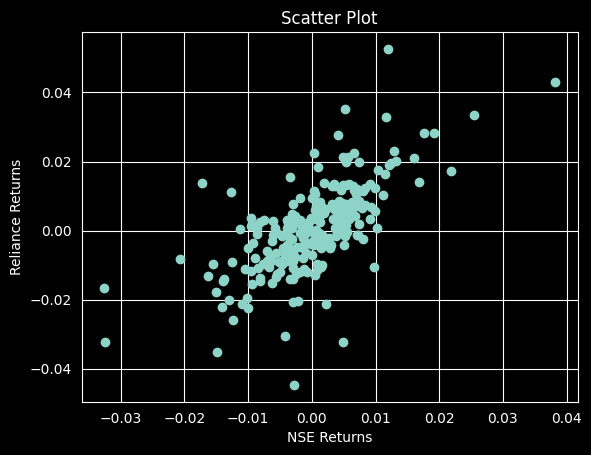

In [2]:
# Downloading Data
end = dt.date.today()
start = end - dt.timedelta(365)
a = yf.download(["RELIANCE.NS", "^NSEI"], start=start, end=end, auto_adjust=True)['Close']

# Cleaning Data
a.columns = ['reliance', 'nse']

# Returns
returns = a.pct_change().dropna()

x = returns['nse']
y = returns['reliance']

plt.scatter(x, y)
plt.xlabel("NSE Returns")
plt.ylabel("Reliance Returns")
plt.title("Scatter Plot")
plt.show()

In [3]:
# Correlation

corr = x.corr(y)
print("Correlation:", corr)

Correlation: 0.6732438628314357


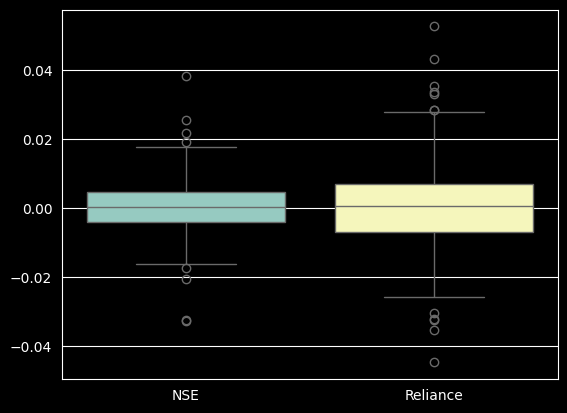

In [4]:
# Outlier Check
sns.boxplot(data=[x, y])
plt.xticks([0,1], ['NSE','Reliance'])
plt.show()

In [5]:
# outlier Check
z_x = np.abs(zscore(x))
z_y = np.abs(zscore(y))

outliers = (z_x > 3) | (z_y > 3)

print("Outliers:\n", returns[outliers])

Outliers:
             reliance       nse
Date                          
2025-04-07 -0.032373 -0.032433
2025-04-28  0.052599  0.012028
2025-05-12  0.043058  0.038183
2026-01-06 -0.044674 -0.002728
2026-02-03  0.033587  0.025476
2026-03-19 -0.016547 -0.032621


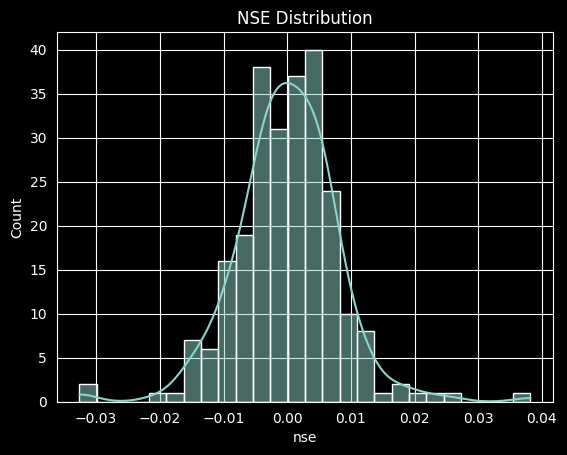

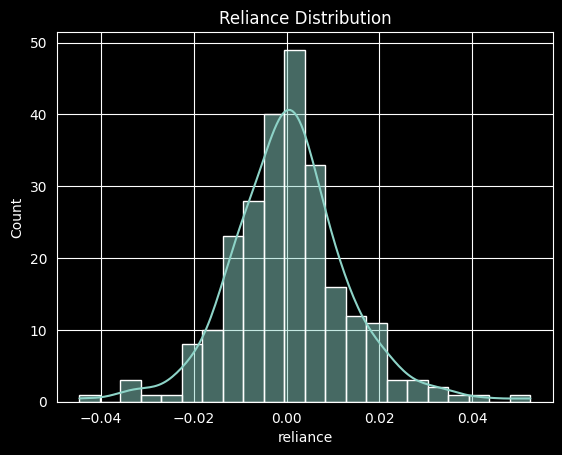

In [6]:
sns.histplot(x, kde=True)
plt.title("NSE Distribution")
plt.show()

sns.histplot(y, kde=True)
plt.title("Reliance Distribution")
plt.show()

In [7]:
# model
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
residuals = model.resid
print(residuals)

Date
2025-03-24    0.005655
2025-03-25   -0.013770
2025-03-26   -0.002014
2025-03-27   -0.001226
2025-03-28    0.000320
                ...   
2026-03-16   -0.001907
2026-03-17   -0.006544
2026-03-18   -0.001860
2026-03-19    0.017557
2026-03-20    0.015669
Length: 247, dtype: float64


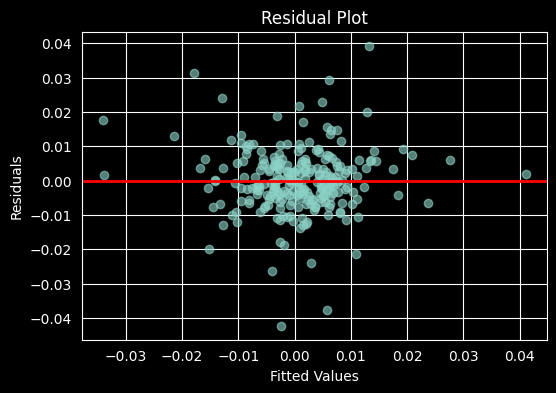

In [8]:
# Residual Plotting
plt.figure(figsize=(6,4))

plt.scatter(model.fittedvalues, residuals, alpha=0.6)  # transparency add
plt.axhline(y=0, color='red', linewidth=2)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

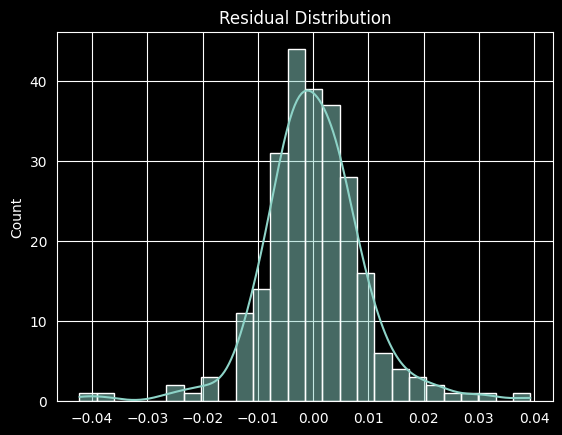

In [9]:
# Residual Distirbution

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

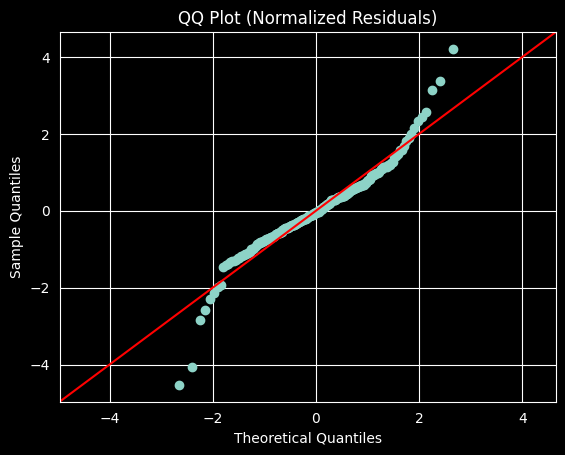

In [10]:
# Normalized  Residual qqplot
sm.qqplot(residuals,fit=True ,line='45')
plt.title("QQ Plot (Normalized Residuals)")
plt.show()

In [11]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               reliance   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     203.1
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           5.69e-34
Time:                        17:46:45   Log-Likelihood:                 803.94
No. Observations:                 247   AIC:                            -1604.
Df Residuals:                     245   BIC:                            -1597.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.874      0.3

In [12]:
print("Dependent Variable → What we are predicting (Y): Reliance Returns")
print("Independent Variable → What drives prediction (X): NSE Returns")
alpha = model.params[0]
print(f"Alpha: {alpha} → Extra return when market is 0 (stock-specific return)")
beta = model.params[1]
print(f"Beta: {beta} → Reliance moves {beta}x of NSE (market sensitivity)")
p_value = model.pvalues[1]
print(f"P-value: {p_value} → {'Significant (real relationship)' if p_value < 0.05 else 'Not significant (random)'}")
t_stat = model.tvalues[1]
print(f"T-stat: {t_stat} → Strength of signal (higher = stronger)")
std_err = model.bse[1]
print(f"Standard Error: {std_err} → Uncertainty in beta (lower = more reliable)")
r2 = model.rsquared
print(f"R²: {r2} → {r2*100:.2f}% of Reliance movement explained by NSE")
adj_r2 = model.rsquared_adj
print(f"Adjusted R²: {adj_r2} → True explanatory power (penalized version)")
f_stat = model.fvalue
print(f"F-statistic: {f_stat} → Overall model usefulness")
f_pval = model.f_pvalue
print(f"F-test p-value: {f_pval} → {'Model is valid' if f_pval < 0.05 else 'Model not useful'}")
mae = np.mean(np.abs(residuals))
print(f"MAE: {mae} → Average prediction error")
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE: {rmse} → Typical prediction error (penalizes large errors)")
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw} → {'No autocorrelation' if 1.8 < dw < 2.2 else 'Autocorrelation present'}")
skew = residuals.skew()
print(f"Skewness: {skew} → {'Symmetric distribution' if abs(skew)<0.5 else 'Skewed distribution'}")
kurt = residuals.kurtosis()
print(f"Kurtosis: {kurt} → {'Fat tails (extreme moves likely)' if kurt>3 else 'Normal tails'}")
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuals)

print(f"Jarque-Bera p-value: {jb_p} → {'Normal distribution' if jb_p>0.05 else 'Not normal'}")

Dependent Variable → What we are predicting (Y): Reliance Returns
Independent Variable → What drives prediction (X): NSE Returns
Alpha: 0.0005211469983767212 → Extra return when market is 0 (stock-specific return)
Beta: 1.061461624598451 → Reliance moves 1.061461624598451x of NSE (market sensitivity)
P-value: 5.689346219830595e-34 → Significant (real relationship)
T-stat: 14.251610625999438 → Strength of signal (higher = stronger)
Standard Error: 0.07448011684111056 → Uncertainty in beta (lower = more reliable)
R²: 0.45325729884019406 → 45.33% of Reliance movement explained by NSE
Adjusted R²: 0.4510256959783173 → True explanatory power (penalized version)
F-statistic: 203.10840543509988 → Overall model usefulness
F-test p-value: 5.6893462198309045e-34 → Model is valid
MAE: 0.006638790196982023 → Average prediction error
RMSE: 0.009337115719518414 → Typical prediction error (penalizes large errors)
Durbin-Watson: 1.9643141198114187 → No autocorrelation
Skewness: -0.05428456719478936 → 